In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/Students suspicious behaviors detection dataset_V1.csv")

le = LabelEncoder()
df['head_pose']      = le.fit_transform(df['head_pose'].astype(str))
df['gaze_direction'] = le.fit_transform(df['gaze_direction'].astype(str))

In [3]:
df.fillna(df.median(numeric_only=True), inplace=True)

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

In [5]:
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

mnb = MultinomialNB()
mnb.fit(X_train_s, y_train)
y_pred_mnb = mnb.predict(X_test_s)

In [6]:
gnb_acc = accuracy_score(y_test, y_pred_gnb)
mnb_acc = accuracy_score(y_test, y_pred_mnb)

print(f"Gaussian NB Accuracy    : {gnb_acc*100:.2f}%")
print(f"Multinomial NB Accuracy : {mnb_acc*100:.2f}%")
print(f"\nBetter Model: {'Gaussian NB' if gnb_acc >= mnb_acc else 'Multinomial NB'}")

print("\nGaussian NB - Classification Report:")
print(classification_report(y_test, y_pred_gnb, target_names=['Normal', 'Suspicious']))

print("Multinomial NB - Classification Report:")
print(classification_report(y_test, y_pred_mnb, target_names=['Normal', 'Suspicious']))

Gaussian NB Accuracy    : 92.27%
Multinomial NB Accuracy : 72.55%

Better Model: Gaussian NB

Gaussian NB - Classification Report:
              precision    recall  f1-score   support

      Normal       0.87      1.00      0.93       569
  Suspicious       1.00      0.84      0.91       531

    accuracy                           0.92      1100
   macro avg       0.93      0.92      0.92      1100
weighted avg       0.93      0.92      0.92      1100

Multinomial NB - Classification Report:
              precision    recall  f1-score   support

      Normal       0.65      1.00      0.79       569
  Suspicious       1.00      0.43      0.60       531

    accuracy                           0.73      1100
   macro avg       0.83      0.72      0.70      1100
weighted avg       0.82      0.73      0.70      1100



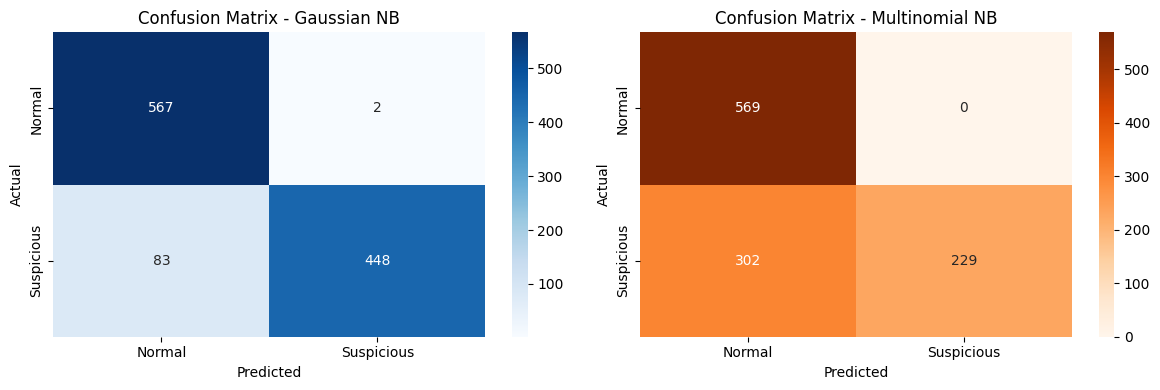

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title, cmap in [
    (axes[0], y_pred_gnb, 'Confusion Matrix - Gaussian NB',    'Blues'),
    (axes[1], y_pred_mnb, 'Confusion Matrix - Multinomial NB', 'Oranges'),
]:
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
                cmap=cmap, xticklabels=['Normal', 'Suspicious'],
                yticklabels=['Normal', 'Suspicious'], ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [8]:
print("\nPredictions on test data (first 10 samples):")
print(f"{'#':<4} {'Actual':<12} {'Gaussian NB':<14} {'Multinomial NB'}")
print("-" * 46)
for i in range(10):
    actual  = 'Suspicious' if y_test.iloc[i] == 1 else 'Normal'
    pred_g  = 'Suspicious' if y_pred_gnb[i]  == 1 else 'Normal'
    pred_m  = 'Suspicious' if y_pred_mnb[i]  == 1 else 'Normal'
    print(f"{i+1:<4} {actual:<12} {pred_g:<14} {pred_m}")


Predictions on test data (first 10 samples):
#    Actual       Gaussian NB    Multinomial NB
----------------------------------------------
1    Normal       Normal         Normal
2    Normal       Normal         Normal
3    Normal       Normal         Normal
4    Normal       Normal         Normal
5    Suspicious   Suspicious     Suspicious
6    Suspicious   Suspicious     Normal
7    Suspicious   Suspicious     Suspicious
8    Suspicious   Suspicious     Normal
9    Normal       Normal         Normal
10   Normal       Normal         Normal
